# Libraries & functions

In [1]:
import pandas as pd
from datetime import timedelta
import plotly.express as px
import plotly.graph_objects as go
import math
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

In [2]:
'''
    Unidad de las entradas:
    -Tmax: en grado celsius
    -Tmin: en grado celsius
    -RHmax: en %
    -RHmin: en %
    -latitud_rad: en radian (lat * math.pi / 180)
    -elevation: en m
    -wind_speed_mean: en m/s
    -solar_radiation_mean: en W m^-2 day^-1
    -Day_of_Year: el día del año
    -sensor_height: la altura del sensor de la velocidad del viento
'''
def PenmanMonteith(Tmax, Tmin, RHmax, RHmin, latitud_rad, elevation, wind_speed_mean, solar_radiation_mean, Day_of_Year, sensor_height):
    
    Tmean = (Tmax + Tmin) / 2

    # Conversion of wind speed
    u_2 = wind_speed_mean*4.87/np.log(67.8*sensor_height-5.42) # wind speed at 2m height

    # Parameters
    P = 101.3*pow((293-0.0065*elevation)/293,5.26) # Atmospheric pressure
    psychrometric_constant = 0.000665 * P
    delta = 4098*(0.6108*math.exp(17.27*Tmean/(Tmean+237.3))) / (Tmean+237.3)**2  # slope vapour pressure curve  

    # Vapour pressure deficit
    e_0_Tmax = 0.6108*math.exp(17.27*Tmax/(Tmax+237.3)) # saturation vapour pressure at daily maximum temperature
    e_0_Tmin = 0.6108*math.exp(17.27*Tmin/(Tmin+237.3)) # saturation vapour pressure at daily minimum temperature
    e_s = (e_0_Tmax + e_0_Tmin) / 2    # saturation vapour pressure 
    e_a = (e_0_Tmin*RHmax/100+e_0_Tmax*RHmin/100)/2 # actual vapour pressure

    # Radiation
    J = Day_of_Year
    d_r = 1 + 0.033 * math.cos(2*math.pi*J/365) # inverse relative distance Earth-Sun
    solar_decimation = 0.409*math.sin(2*math.pi*J/365-1.39)
    sunset_hour_angle = math.acos(-math.tan(latitud_rad)*math.tan(solar_decimation))
    R_a = 24 * 60 / math.pi * 0.0820 * d_r * (sunset_hour_angle*math.sin(latitud_rad)*math.sin(solar_decimation)+math.cos(latitud_rad)*math.cos(solar_decimation)*math.sin(sunset_hour_angle)) # Extraterrestrial radiation for daily periods

    # N = 24 * sunset_hour_angle / math.pi # numero de horas de sol (teorico)
    # n -> duración del numero de hora de sol (real) -> Se puede sacar o bien por la estación meteorológicas, o bien calculado por las radiaciones (nº horas donde la radiacion es > 120 W/m^2) https://library.wmo.int/doc_num.php?explnum_id=3154
    # n y N se pueden utilizar para sacar la radiacion solar R_s: https://www.fao.org/3/X0490E/x0490e07.htm (formula 35)

    R_so = (0.75 + (2 * math.pow(10,-5)) * elevation) * R_a # Clear-sky solar radiation
    
    R_s = solar_radiation_mean * 0.0864 # Solar radiation: (W/m^2) to (MJ m^-2 day^-1) https://www.fao.org/3/X0490E/x0490e0i.htm 
    R_ns = (1-0.23)*R_s # incoming net shortwave radiation 
    R_nl = 4.903 * math.pow(10,-9) * (math.pow((Tmax + 273.16), 4) + math.pow((Tmin + 273.16),4))/2 * (0.34 - 0.14 * math.sqrt(e_a)) * (1.35 * R_s/R_so - 0.35) # outgoing net longwave radiation
    R_n = R_ns - R_nl # Net radiation
    
    # ETo
    G = 0 # is ignored for daily calculations as the magnitude of the flux in this case is relatively small
    ETo = (0.408 * delta * (R_n - G) + psychrometric_constant * 900 * u_2 * (e_s - e_a)/(Tmean + 273))/(delta +  psychrometric_constant * (1 + 0.34 * u_2))

    return ETo

In [3]:
df_meteo = pd.read_csv('../FloraPulse - Datos/JU52 SIAM Horario.csv', sep=';', decimal=',')[['FECHA', 'HORA', 'TMAX', 'TMIN', 'HRMAX', 'HRMIN', 'RADMED', 'VVMED', 'PREC']]
df_meteo['DateTime'] = pd.to_datetime(df_meteo['FECHA'] + ' ' + df_meteo['HORA'], dayfirst=True)
df_meteo.drop(columns=['FECHA', 'HORA'], inplace=True)
df_meteo

C:\Users\psyey\AppData\Local\Temp\ipykernel_17616\2990922715.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_meteo['DateTime'] = pd.to_datetime(df_meteo['FECHA'] + ' ' + df_meteo['HORA'], dayfirst=True)


,TMAX,TMIN,HRMAX,HRMIN,RADMED,VVMED,PREC,DateTime
0,3.854,2.519,86.1,80.50,0.0,0.932,0.0,2023-01-01 00:00:00
1,3.383,1.625,88.8,83.00,0.0,0.342,0.0,2023-01-01 01:00:00
2,2.579,1.436,88.5,85.90,0.0,0.609,0.0,2023-01-01 02:00:00
3,2.675,1.484,88.9,84.50,0.0,0.727,0.0,2023-01-01 03:00:00
4,3.056,1.912,87.4,83.20,0.0,0.490,0.0,2023-01-01 04:00:00
...,...,...,...,...,...,...,...,...
26337,6.125,4.934,82.5,77.03,0.0,0.354,0.0,2025-12-31 19:00:00
26338,5.219,3.948,84.4,80.90,0.0,0.413,0.0,2025-12-31 20:00:00
26339,4.332,2.669,87.7,82.10,0.0,0.455,0.0,2025-12-31 21:00:00
26340,3.389,2.101,92.0,87.10,0.0,0.457,0.0,2025-12-31 22:00:00


In [4]:
# Read the kc dates and its values
fechas_kc_2023 = pd.read_excel('../FloraPulse - Datos/DATOS FP/2023/kc_2023.xlsx', usecols='B:D')
fechas_kc_2023.dropna(inplace=True)
fechas_kc_2023

,Start,End,Kc
0,2023-04-10,2023-04-16,0.55
1,2023-04-17,2023-04-23,0.55
2,2023-04-24,2023-04-30,0.55
3,2023-05-01,2023-05-07,0.55
4,2023-05-08,2023-05-14,0.55
5,2023-05-15,2023-05-21,0.55
6,2023-05-22,2023-05-28,0.55
7,2023-05-29,2023-06-04,0.55
8,2023-06-05,2023-06-11,0.58
9,2023-06-12,2023-06-18,0.62


In [5]:
# Find the corresponding kc value of the date x
def getKc_2023(x):
    for i in range(0,len(fechas_kc_2023)):
        if (x >= fechas_kc_2023['Start'][i]) & (x < fechas_kc_2023['End'][i] + timedelta(days=1)):
            return fechas_kc_2023['Kc'][i]

In [9]:
# hourly aggregation
hourly_agg = {
    'FLORAPULSE': 'mean',
    'SWC - 35-55cm': 'mean',
    'Riego (L)': 'sum'
}

# daily aggregation
daily_agg = {
    #'FLORAPULSE': 'mean',  
    'SWC - 35-55cm': 'mean',  
    'Riego (L)': 'sum',  
    #'Kc': 'first',
    'TMAX': 'max',                
    'TMIN': 'min',                
    'HRMAX': 'max',                
    'HRMIN': 'min',                 
    'RADMED': 'mean',              
    'VVMED': 'mean',
    'PREC': 'sum'                  
}

# Compute ETo using Penman-Monteith with daily max/min temperature and humidity
lat_rad = 38.485886 * math.pi / 180
elevation = 547  # meters
sensor_height = 2  # meters


def compute_effective_precipitation(df_resampled, rain_col, threshold=75, clip_negative=True):
    """Compute monthly and daily effective precipitation (PE).

    Monthly P is the sum of daily `rain_col` per month.

    Monthly PE rule (per month):
      - if P >= threshold: PE = 0.8 * P - 25
      - else:               PE = 0.6 * P - 10

    Monthly PE is clipped to 0 if `clip_negative` is True.

    Daily PE is distributed proportionally:
      daily_PE = monthly_PE * Pd / P  (Pd is the daily rain_col)

    Returns a new DataFrame (copy) with added columns:
      - `monthly_P`   : total precipitation per month
      - `monthly_PE`  : effective precipitation for that month
      - `PE_daily`    : daily effective precipitation assigned proportionally
    """
    df = df_resampled.copy()

    # Ensure a DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'timestamp' in df.columns:
            df = df.set_index(pd.to_datetime(df['timestamp']))
        else:
            raise ValueError("DataFrame must have a DatetimeIndex or a 'timestamp' column")

    # Map each day to its month period
    df['year_month'] = df.index.to_period('M')

    # Monthly total P
    monthly = df.groupby('year_month')[rain_col].sum().rename('monthly_P').to_frame()

    # Monthly PE calculation
    monthly['monthly_PE'] = np.where(monthly['monthly_P'] >= threshold,
                                     0.8 * monthly['monthly_P'] - 25,
                                     0.6 * monthly['monthly_P'] - 10)

    if clip_negative:
        monthly['monthly_PE'] = monthly['monthly_PE'].clip(lower=0)

    # Bring monthly values back to daily rows
    df = df.merge(monthly, how='left', left_on='year_month', right_index=True)

    # Compute daily PE proportionally; handle months with P == 0
    df['PE_daily'] = 0.0
    mask = df['monthly_P'] > 0
    df.loc[mask, 'PE_daily'] = (df.loc[mask, 'monthly_PE'] *
                                df.loc[mask, rain_col] / df.loc[mask, 'monthly_P'])

    # Clean helper column
    df = df.drop(columns=['year_month'])

    return df



def calculate_NNR(path, kc_file, df_meteo, numero_arboles=333, start_date='2023-5-2', end_date='2023-10-17', marco_plantacion=5.5*3, dates_to_drop=[]):
    # Read data 
    df_fp = pd.read_excel('../FloraPulse - Datos/DATOS FP/2023/' + path, usecols='E,F, N, V')
    df_fp['DateTime'] = pd.to_datetime(df_fp['DateTime'])

    # Read the kc dates and its values
    df_kc = pd.read_csv('../FloraPulse - Datos/IMIDA Kc/' + kc_file)
    df_kc['date'] = pd.to_datetime(df_kc['date'])
    # minus two years for each date, to be able to merge with the 2023 data
    df_kc['date'] = df_kc['date'].apply(lambda x: x - timedelta(days=365*2))
    df_kc.columns = ['DateTime', kc_file.split('.')[0]]

    df_fp = df_fp.resample('1h', on='DateTime').agg(hourly_agg) # Resampling de 1h

    # Set the kc value for each date (row) using the function getKc()
    kcs = df_fp.reset_index()['DateTime'].apply(lambda x: getKc_2023(x))
    df_fp['Kc'] = kcs.values

    # Select range of dates
    df_fp = df_fp[(df_fp.index >= start_date) & (df_fp.index <= end_date)].copy()

    # Merge with meteo data
    df_final_hourly = pd.merge(df_fp.reset_index(), df_meteo, how='left', on='DateTime')
    df_final_hourly.set_index('DateTime', inplace=True)

    df_final_hourly = df_final_hourly.drop(columns=['FLORAPULSE', 'Kc']) # drop the columns that are not needed for the calculations

    # Plot hourly data
    #fig = go.Figure()
    #for c in df_final_hourly.columns:
    #    fig.add_trace(go.Scatter(x=df_final_hourly.index, y=df_final_hourly[c], name=c))
        
    #fig.update_layout(hovermode="x unified")
    #fig.show()

    # Resample to daily data
    df_final_daily = df_final_hourly.resample('D').agg(daily_agg)

    # Use the raw daily aggregated data
    df_final_daily = df_final_daily.reset_index()

    # Add IMIDA Kc values to the daily dataframe
    df_final_daily = pd.merge(df_final_daily, df_kc, on='DateTime', how='left')

    # Calculate ETo and ETc
    df_final_daily['ETo_daily'] = df_final_daily.apply(lambda x: PenmanMonteith(x.TMAX,x.TMIN, x.HRMAX, x.HRMIN, lat_rad, elevation, x.VVMED, x.RADMED, x.DateTime.timetuple().tm_yday, sensor_height),axis=1)
    df_final_daily['ETc_IMIDA'] = df_final_daily[kc_file.split('.')[0]] * df_final_daily['ETo_daily']
    df_final_daily.set_index('DateTime', inplace=True)

    # Compute effective precipitation
    df_final_daily = compute_effective_precipitation(df_final_daily, rain_col='PREC')

    # Compute NNR
    df_final_daily['NNR_IMIDA'] = df_final_daily.apply(lambda x: (x.ETc_IMIDA - x.PE_daily) * marco_plantacion * numero_arboles , axis=1).clip(0)

    # drop specified period of dates
    if len(dates_to_drop) > 0:
        df_final_daily = df_final_daily.drop(index=dates_to_drop)

    # Plot
    fig = go.Figure()
    for c in df_final_daily.columns:
        fig.add_trace(go.Scatter(x=df_final_daily.index, y=df_final_daily[c], name=c))
        
    fig.update_layout(hovermode="x unified")
    fig.show()

    # Print summary statistics
    print(path)
    print(kc_file)
    print('Suma Riego real:', df_final_daily['Riego (L)'].sum(),'L')
    print('Suma NNR_IMIDA:', df_final_daily['NNR_IMIDA'].sum(),'L')
    print('Diferencia (NNR_IMIDA - Riego):', df_final_daily['NNR_IMIDA'].sum() - df_final_daily['Riego (L)'].sum(),'L')
    print('Diferencia porcentaje:', (df_final_daily['NNR_IMIDA'].sum() - df_final_daily['Riego (L)'].sum()) / df_final_daily['Riego (L)'].sum() * 100)

    return df_final_daily

In [7]:
plots2023 = [
    'T1.2._2023.xlsx',
    'T2.1._2023.xlsx',
    'T3.1._2023.xlsx',
    'T4.1._2023.xlsx',
]

num_trees = [
    315,
    312,
    323,
    305
]

In [10]:
final_dfs = []

for i in range(len(plots2023)):
    if plots2023[i] == 'T2.1._2023.xlsx':
        # drop the period between 2023-07-08 and 2023-07-20, where there was a problem with the irrigation system
        dates_to_drop = pd.date_range(start='2023-07-08', end='2023-07-20')
    elif plots2023[i] == 'T4.1._2023.xlsx':
        # drop the period between 2023-07-01 and 2023-07-15, where there was a problem with the irrigation system
        dates_to_drop = pd.date_range(start='2023-10-15', end='2023-10-17')
    else:
        dates_to_drop = []
    final_dfs.append(calculate_NNR(plots2023[i], kc_file='MO51_Melocotonero_Temprano_kc.csv', df_meteo=df_meteo, 
                    numero_arboles=num_trees[i], start_date='2023-5-2', end_date='2023-10-17', 
                    marco_plantacion=5.5*3, dates_to_drop=dates_to_drop))
    

T1.2._2023.xlsx
MO51_Melocotonero_Temprano_kc.csv
Suma Riego real: 1989200.0 L
Suma NNR_IMIDA: 1828066.956740171 L
Diferencia (NNR_IMIDA - Riego): -161133.04325982905 L
Diferencia porcentaje: -8.100394292169167


T2.1._2023.xlsx
MO51_Melocotonero_Temprano_kc.csv
Suma Riego real: 1788450.0 L
Suma NNR_IMIDA: 1615463.0891344035 L
Diferencia (NNR_IMIDA - Riego): -172986.9108655965 L
Diferencia porcentaje: -9.672448816885934


T3.1._2023.xlsx
MO51_Melocotonero_Temprano_kc.csv
Suma Riego real: 2075850.0 L
Suma NNR_IMIDA: 1874494.054054207 L
Diferencia (NNR_IMIDA - Riego): -201355.94594579306 L
Diferencia porcentaje: -9.699927545140211


T4.1._2023.xlsx
MO51_Melocotonero_Temprano_kc.csv
Suma Riego real: 2052050.0000000002 L
Suma NNR_IMIDA: 1759211.1448618956 L
Diferencia (NNR_IMIDA - Riego): -292838.85513810464 L
Diferencia porcentaje: -14.270551650208551


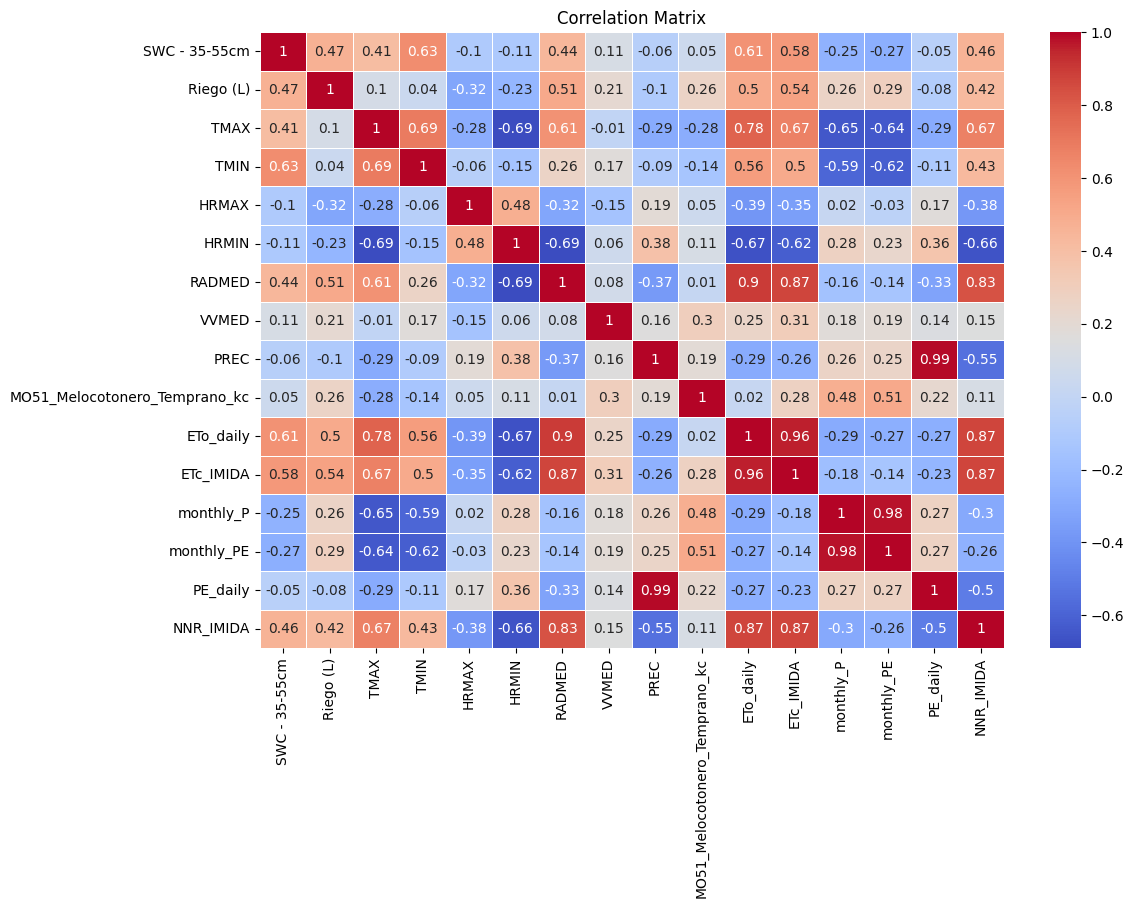

In [11]:
# Calculate the correlation matrix
correlation_matrix = final_dfs[0].corr().round(2)

# Plot a heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# NNR estimation

In [12]:
def CVRMSE(y_pred, y_true):
    y_pred, y_true = np.array(y_pred), np.array(y_true)
    return root_mean_squared_error(y_true, y_pred)/np.mean(y_true)*100

In [16]:
final_dfs[0].columns

Index(['SWC - 35-55cm', 'Riego (L)', 'TMAX', 'TMIN', 'HRMAX', 'HRMIN',
       'RADMED', 'VVMED', 'PREC', 'MO51_Melocotonero_Temprano_kc', 'ETo_daily',
       'ETc_IMIDA', 'monthly_P', 'monthly_PE', 'PE_daily', 'NNR_IMIDA'],
      dtype='str')

In [29]:
# concatenate the 4 dataframes of the 4 plots
pd.concat(final_dfs, axis=0)

,SWC - 35-55cm,Riego (L),TMAX,TMIN,HRMAX,HRMIN,RADMED,VVMED,PREC,MO51_Melocotonero_Temprano_kc,ETo_daily,ETc_IMIDA,monthly_P,monthly_PE,PE_daily,NNR_IMIDA
DateTime,,,,,,,,,,,,,,,,
2023-05-02,46.835840,12400.0,30.10,9.080,90.50,10.00,316.567500,1.287958,0.0,0.35,5.528829,1.935090,66.6,29.96,0.0,10057.630319
2023-05-03,48.855920,24800.0,27.62,7.363,62.71,15.88,301.803333,1.377417,0.0,0.35,5.232199,1.831270,66.6,29.96,0.0,9518.023297
2023-05-04,49.816985,24600.0,28.95,7.363,62.09,21.16,287.292500,0.984167,0.0,0.35,4.777648,1.672177,66.6,29.96,0.0,8691.138431
2023-05-05,50.368816,24400.0,29.81,10.120,73.87,18.30,345.279167,1.336583,0.0,0.35,5.819970,2.036990,66.6,29.96,0.0,10587.253389
2023-05-06,49.570852,24400.0,30.24,9.740,63.17,14.90,338.335417,1.252500,0.0,0.35,5.761199,2.016420,66.6,29.96,0.0,10480.342024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-10,49.988563,0.0,26.14,11.870,95.60,44.12,212.868750,0.823917,0.0,0.40,2.781380,1.112552,1.6,0.00,0.0,5598.918877
2023-10-11,47.798806,0.0,26.90,11.640,96.70,37.79,200.680833,0.706667,0.0,0.40,2.652833,1.061133,1.6,0.00,0.0,5340.151862
2023-10-12,49.828542,0.0,28.38,11.640,98.30,24.46,183.117500,0.829792,0.0,0.40,2.750745,1.100298,1.6,0.00,0.0,5537.249882


## Probar con ETc y PE_diario como entrada y tuning de hiperparametros

In [13]:
tscv = TimeSeriesSplit(n_splits=3)

svr_param_grid = {
    'svr__C': [1, 100, 1000, 10000, 100000],
    'svr__epsilon': [0.01, 0.1, 0.5, 1, 10],
    'svr__gamma': ['scale', 'auto']
}

rf_param_grid = {
    'max_depth': [None, 5, 10, 20, 50],
    'max_features': [None, 'sqrt', 'log2'],
    'n_estimators': [100, 500, 1000, 2000]
}

for i in range(len(final_dfs)):

    plot_df = final_dfs[i].copy()
    print(f"{'='*80}")
    print(f"PLOT: {plots2023[i]}")
    print(f"{'='*80}")

    # Define features and target
    features = ['ETc_IMIDA', 'PE_daily'] 
    target = 'NNR_IMIDA'

    # Drop rows with NaN in features or target
    plot_df = plot_df.dropna(subset=features + [target])

    # Prepare X and y
    X = plot_df[features]
    y = plot_df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, shuffle=False)
    # Print the number of samples in train and test sets
    print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

    # Grid Search for SVR
    print("Performing Grid Search for SVR...")
    svr_grid_search = GridSearchCV(make_pipeline(StandardScaler(), SVR(kernel='rbf')), svr_param_grid, cv=tscv, scoring='neg_mean_absolute_error')
    svr_grid_search.fit(X_train, y_train)

    # Grid Search for RF
    print("Performing Grid Search for Random Forest...")
    rf_grid_search = GridSearchCV(RandomForestRegressor(random_state=123), rf_param_grid, cv=tscv, scoring='neg_mean_absolute_error')
    rf_grid_search.fit(X_train, y_train)


    # SVR predictions
    y_pred_svr = svr_grid_search.best_estimator_.predict(X_test)
    svr_mae = mean_absolute_error(y_test, y_pred_svr)
    svr_r2 = np.corrcoef(y_test, y_pred_svr)[0][1]**2
    svr_cv_rmse = CVRMSE(y_pred_svr, y_test)

    # RF predictions
    y_pred_rf = rf_grid_search.best_estimator_.predict(X_test)
    rf_mae = mean_absolute_error(y_test, y_pred_rf)
    rf_r2 = np.corrcoef(y_test, y_pred_rf)[0][1]**2
    rf_cv_rmse = CVRMSE(y_pred_rf, y_test)

    print(f'Plot: {plots2023[i]}')
    print(f'SVR - MAE: {svr_mae:.2f}, R2: {svr_r2:.2f}, CV-RMSE: {svr_cv_rmse:.2f}%')
    print(f'RF - MAE: {rf_mae:.2f}, R2: {rf_r2:.2f}, CV-RMSE: {rf_cv_rmse:.2f}%')
    print('---')

PLOT: T1.2._2023.xlsx
Train samples: 135, Test samples: 34
Performing Grid Search for SVR...
Performing Grid Search for Random Forest...
Plot: T1.2._2023.xlsx
SVR - MAE: 239.15, R2: 0.96, CV-RMSE: 6.97%
RF - MAE: 959.58, R2: 0.65, CV-RMSE: 24.16%
---
PLOT: T2.1._2023.xlsx
Train samples: 124, Test samples: 32
Performing Grid Search for SVR...
Performing Grid Search for Random Forest...
Plot: T2.1._2023.xlsx
SVR - MAE: 199.71, R2: 0.97, CV-RMSE: 6.08%
RF - MAE: 1110.21, R2: 0.53, CV-RMSE: 27.78%
---
PLOT: T3.1._2023.xlsx
Train samples: 135, Test samples: 34
Performing Grid Search for SVR...
Performing Grid Search for Random Forest...
Plot: T3.1._2023.xlsx
SVR - MAE: 244.68, R2: 0.96, CV-RMSE: 6.95%
RF - MAE: 984.59, R2: 0.65, CV-RMSE: 24.17%
---
PLOT: T4.1._2023.xlsx
Train samples: 132, Test samples: 34
Performing Grid Search for SVR...
Performing Grid Search for Random Forest...
Plot: T4.1._2023.xlsx
SVR - MAE: 186.44, R2: 1.00, CV-RMSE: 4.33%
RF - MAE: 756.43, R2: 0.77, CV-RMSE: 17.66%

## Probar con todas las entrada y tuning de hiperparametros

In [14]:
tscv = TimeSeriesSplit(n_splits=3)

svr_param_grid = {
    'svr__C': [1, 100, 1000, 10000, 100000],
    'svr__epsilon': [0.01, 0.1, 0.5, 1, 10],
    'svr__gamma': ['scale', 'auto']
}

rf_param_grid = {
    'max_depth': [None, 5, 10, 20, 50],
    'max_features': [None, 'sqrt', 'log2'],
    'n_estimators': [100, 500, 1000, 2000]
}

for i in range(len(final_dfs)):

    plot_df = final_dfs[i].copy()
    print(f"{'='*80}")
    print(f"PLOT: {plots2023[i]}")
    print(f"{'='*80}")

    # Define features and target
    features = ['SWC - 35-55cm', 'Riego (L)', 'TMAX', 'TMIN', 'HRMAX', 'HRMIN',
       'RADMED', 'VVMED', 'PREC', 'MO51_Melocotonero_Temprano_kc', 'ETo_daily',
       'ETc_IMIDA', 'monthly_P', 'monthly_PE', 'PE_daily', 'NNR_IMIDA'] 
    target = 'NNR_IMIDA'

    # Drop rows with NaN in features or target
    plot_df = plot_df.dropna(subset=features + [target])

    # Prepare X and y
    X = plot_df[features]
    y = plot_df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, shuffle=False)
    # Print the number of samples in train and test sets
    print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

    # Grid Search for SVR
    print("Performing Grid Search for SVR...")
    svr_grid_search = GridSearchCV(make_pipeline(StandardScaler(), SVR(kernel='rbf')), svr_param_grid, cv=tscv, scoring='neg_mean_absolute_error')
    svr_grid_search.fit(X_train, y_train)

    # Grid Search for RF
    print("Performing Grid Search for Random Forest...")
    rf_grid_search = GridSearchCV(RandomForestRegressor(random_state=123), rf_param_grid, cv=tscv, scoring='neg_mean_absolute_error')
    rf_grid_search.fit(X_train, y_train)


    # SVR predictions
    y_pred_svr = svr_grid_search.best_estimator_.predict(X_test)
    svr_mae = mean_absolute_error(y_test, y_pred_svr)
    svr_r2 = np.corrcoef(y_test, y_pred_svr)[0][1]**2
    svr_cv_rmse = CVRMSE(y_pred_svr, y_test)

    # RF predictions
    y_pred_rf = rf_grid_search.best_estimator_.predict(X_test)
    rf_mae = mean_absolute_error(y_test, y_pred_rf)
    rf_r2 = np.corrcoef(y_test, y_pred_rf)[0][1]**2
    rf_cv_rmse = CVRMSE(y_pred_rf, y_test)

    print(f'Plot: {plots2023[i]}')
    print(f'SVR - MAE: {svr_mae:.2f}, R2: {svr_r2:.2f}, CV-RMSE: {svr_cv_rmse:.2f}%')
    print(f"  Best params SVR: {svr_grid_search.best_params_}")
    print(f'RF - MAE: {rf_mae:.2f}, R2: {rf_r2:.2f}, CV-RMSE: {rf_cv_rmse:.2f}%')
    print(f"  Best params RF: {rf_grid_search.best_params_}")
    print('---')

PLOT: T1.2._2023.xlsx
Train samples: 135, Test samples: 34
Performing Grid Search for SVR...
Performing Grid Search for Random Forest...
Plot: T1.2._2023.xlsx
SVR - MAE: 1089.62, R2: 0.74, CV-RMSE: 23.69%
  Best params SVR: {'svr__C': 100000, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
RF - MAE: 368.49, R2: 0.96, CV-RMSE: 7.91%
  Best params RF: {'max_depth': None, 'max_features': None, 'n_estimators': 100}
---
PLOT: T2.1._2023.xlsx
Train samples: 124, Test samples: 32
Performing Grid Search for SVR...
Performing Grid Search for Random Forest...
Plot: T2.1._2023.xlsx
SVR - MAE: 2040.55, R2: 0.36, CV-RMSE: 42.18%
  Best params SVR: {'svr__C': 1000, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
RF - MAE: 264.68, R2: 0.97, CV-RMSE: 6.90%
  Best params RF: {'max_depth': None, 'max_features': None, 'n_estimators': 2000}
---
PLOT: T3.1._2023.xlsx
Train samples: 135, Test samples: 34
Performing Grid Search for SVR...
Performing Grid Search for Random Forest...
Plot: T3.1._2023.xlsx
SVR - MAE:

## Probar con feature selection (concatenando todas las parcelas) y luego tuning de hiperparametros

In [ ]:
from itertools import combinations

tscv = TimeSeriesSplit(n_splits=3)

svr_param_grid = {
    'svr__C': [1, 100, 1000, 10000, 100000],
    'svr__epsilon': [0.01, 0.1, 0.5, 1, 10],
    'svr__gamma': ['scale', 'auto']
}

rf_param_grid = {
    'max_depth': [None, 5, 10, 20, 50],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'],
    'n_estimators': [100, 500, 1000, 2000]
}

# Define features to try 
all_features = ['SWC - 35-55cm', 'TMAX', 'TMIN', 'HRMAX', 'HRMIN',
       'RADMED', 'VVMED', 'PREC', 'MO51_Melocotonero_Temprano_kc', 'ETo_daily',
       'ETc_IMIDA', 'PE_daily']
target = 'NNR_IMIDA'

# Use all plots combined for feature selection
combined_df = pd.concat(final_dfs, axis=0)
combined_df = combined_df.dropna(subset=all_features + [target])

best_features_svr = None
best_r2_svr = -1
best_features_rf = None
best_r2_rf = -1

feature_combinations = []
for r in range(1, len(all_features) + 1):
    feature_combinations.extend(combinations(all_features, r))

print(f"Selecting best features using combined data from {len(final_dfs)} plots...")
print(f"Testing {len(feature_combinations)} feature combinations on combined data...")

for features in feature_combinations:
    features = list(features)
    test_df = combined_df.dropna(subset=features + [target])
    if len(test_df) < 20:
        continue

    X = test_df[features]
    y = test_df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

    try:
        svr_model = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
        svr_model.fit(X_train, y_train)
        y_pred_svr = svr_model.predict(X_test)
        svr_r2 = np.corrcoef(y_test, y_pred_svr)[0][1]**2
        if svr_r2 > best_r2_svr:
            best_r2_svr = svr_r2
            best_features_svr = features

        rf_model = RandomForestRegressor(random_state=42, n_estimators=500)
        rf_model.fit(X_train, y_train)
        y_pred_rf = rf_model.predict(X_test)
        rf_r2 = np.corrcoef(y_test, y_pred_rf)[0][1]**2
        if rf_r2 > best_r2_rf:
            best_r2_rf = rf_r2
            best_features_rf = features

    except Exception:
        continue

print(f"Best combined features for SVR: {best_features_svr} (R2={best_r2_svr:.4f})")
print(f"Best combined features for RF: {best_features_rf} (R2={best_r2_rf:.4f})")

all_results = []
for i in range(len(final_dfs)):
    plot_df = final_dfs[i].copy()
    print(f"{'='*80}")
    print(f"PLOT: {plots2023[i]}")
    print(f"{'='*80}")

    plot_result = {'plot': plots2023[i]}

    for model_name, features in [('SVR', best_features_svr), ('RF', best_features_rf)]:
        if features is None:
            continue

        plot_test_df = plot_df.dropna(subset=list(features) + [target])
        if len(plot_test_df) < 20:
            print(f"Plot {plots2023[i]}: not enough rows for {model_name} with selected features.")
            continue

        X = plot_test_df[list(features)]
        y = plot_test_df[target]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

        if model_name == 'SVR':
            grid = GridSearchCV(
                make_pipeline(StandardScaler(), SVR(kernel='rbf')),
                param_grid=svr_param_grid,
                cv=tscv,
                scoring='neg_mean_absolute_error',
                n_jobs=-1,
                verbose=0
            )
        else:
            grid = GridSearchCV(
                RandomForestRegressor(random_state=42),
                param_grid=rf_param_grid,
                cv=tscv,
                scoring='neg_mean_absolute_error',
                n_jobs=-1,
                verbose=0
            )

        grid.fit(X_train, y_train)
        y_pred = grid.best_estimator_.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = np.corrcoef(y_test, y_pred)[0][1]**2
        cv_rmse = CVRMSE(y_pred, y_test)

        plot_result[f'{model_name}_features'] = features
        plot_result[f'{model_name}_best_params'] = grid.best_params_
        plot_result[f'{model_name}_mae'] = mae
        plot_result[f'{model_name}_r2'] = r2
        plot_result[f'{model_name}_cv_rmse'] = cv_rmse

        print(f"{model_name} using features {features}")
        print(f"  Best params: {grid.best_params_}")
        print(f"  MAE: {mae:.2f}, R2: {r2:.4f}, CV-RMSE: {cv_rmse:.2f}%")

    all_results.append(plot_result)

print(f"{'='*80}")
print("SUMMARY OF ALL PLOTS")
print(f"{'='*80}")
for result in all_results:
    print(f"Plot: {result['plot']}")
    print(f"  SVR - R2: {result.get('SVR_r2', float('nan')):.4f}, MAE: {result.get('SVR_mae', float('nan')):.2f}")
    print(f"  RF  - R2: {result.get('RF_r2', float('nan')):.4f}, MAE: {result.get('RF_mae', float('nan')):.2f}")
    print()


Selecting best features using combined data from 4 plots...
Testing 4095 feature combinations on combined data...
Best combined features for SVR: ['SWC - 35-55cm', 'HRMIN', 'RADMED', 'VVMED', 'PREC', 'MO51_Melocotonero_Temprano_kc', 'PE_daily'] (R2=0.7194)
Best combined features for RF: ['TMAX', 'HRMAX', 'RADMED', 'MO51_Melocotonero_Temprano_kc', 'PE_daily'] (R2=0.9985)
PLOT: T1.2._2023.xlsx
SVR using features ['SWC - 35-55cm', 'HRMIN', 'RADMED', 'VVMED', 'PREC', 'MO51_Melocotonero_Temprano_kc', 'PE_daily']
  Best params: {'svr__C': 100000, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
  MAE: 2324.17, R2: 0.7989, CV-RMSE: 37.09%
RF using features ['TMAX', 'HRMAX', 'RADMED', 'MO51_Melocotonero_Temprano_kc', 'PE_daily']
  Best params: {'criterion': 'friedman_mse', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
  MAE: 2460.51, R2: 0.7019, CV-RMSE: 40.04%
PLOT: T2.1._2023.xlsx
SVR using features ['SWC - 35-55cm', 'HRMIN', 'RADMED', 'VVMED', 'PREC', 'MO51_Melocotonero_Tempra

## Con LSTM (no probado aun)

In [ ]:
# Helper function to train models using TimeSeriesSplit CV structure
# This allows LSTM and other DL models to be trained with the same cross-validation strategy as tree/SVM models

def train_model_with_tscv(plot_df, features, target, tscv_splitter, model_type='svr', **model_kwargs):
    """
    Train a model using TimeSeriesSplit cross-validation structure.
    
    Parameters:
    - plot_df: DataFrame with features and target
    - features: list of feature column names
    - target: target column name
    - tscv_splitter: TimeSeriesSplit object (defines the splits)
    - model_type: 'svr', 'rf', 'lstm', 'gru'
    - model_kwargs: additional parameters for the model
    
    Returns:
    - predictions across all test folds
    - indices for tracking which samples are from which fold
    """
    
    # Drop NaN values
    test_df = plot_df.dropna(subset=features + [target])
    X = test_df[features].values
    y = test_df[target].values
    
    all_predictions = []
    all_y_test = []
    fold_indices = []
    
    for fold, (train_idx, test_idx) in enumerate(tscv_splitter.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        fold_indices.append(test_idx)
        
        if model_type == 'svr':
            model = make_pipeline(StandardScaler(), SVR(**model_kwargs))
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
        elif model_type == 'rf':
            model = RandomForestRegressor(**model_kwargs)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
        elif model_type in ['lstm', 'gru']:
            # For neural networks, prepare sequential data
            scaler_X = MinMaxScaler()
            scaler_y = MinMaxScaler()
            X_train_scaled = scaler_X.fit_transform(X_train)
            X_test_scaled = scaler_X.transform(X_test)
            y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
            y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))
            
            n_steps = 7
            X_rnn_train = np.array([X_train_scaled[j-n_steps:j] for j in range(n_steps, len(X_train_scaled))])
            y_rnn_train = y_train_scaled[n_steps:]
            X_rnn_test = np.array([X_test_scaled[max(0,j-n_steps):j] for j in range(n_steps, len(X_test_scaled))])
            y_rnn_test = y_test_scaled[n_steps:]
            
            if len(X_rnn_train) < 5 or len(X_rnn_test) < 1:
                continue
            
            model = tf.keras.Sequential()
            if model_type == 'lstm':
                model.add(tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(n_steps, X.shape[1])))
                model.add(tf.keras.layers.Dropout(0.2))
                model.add(tf.keras.layers.LSTM(50))
            else:  # gru
                model.add(tf.keras.layers.GRU(50, return_sequences=True, input_shape=(n_steps, X.shape[1])))
                model.add(tf.keras.layers.Dropout(0.2))
                model.add(tf.keras.layers.GRU(50))
            
            model.add(tf.keras.layers.Dropout(0.2))
            model.add(tf.keras.layers.Dense(1))
            model.compile(optimizer='adam', loss='mse')
            
            early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            model.fit(X_rnn_train, y_rnn_train, epochs=100, batch_size=16, 
                     validation_split=0.2, callbacks=[early_stop], verbose=0)
            
            y_pred_scaled = model.predict(X_rnn_test, verbose=0)
            y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
            y_test = scaler_y.inverse_transform(y_rnn_test).flatten()
        
        all_predictions.extend(y_pred)
        all_y_test.extend(y_test)
    
    return np.array(all_predictions), np.array(all_y_test), fold_indices

# Example: To use this function with LSTM on the best features found above:
# 1. Get best_features_svr or best_features_rf from all_results
# 2. Call: preds, actuals, folds = train_model_with_tscv(final_dfs[i], best_features, 'NNR_IMIDA', tscv, model_type='lstm')
# 3. Calculate metrics: mae = mean_absolute_error(actuals, preds), etc.


In [ ]:
for i in range(len(final_dfs)):

    plot_df = final_dfs[i].copy()

    #plot_df['NNR_IMIDA'] = plot_df['NNR_IMIDA'].shift(1)  # Predict 1 day ahead

    # Add lagged features (7 days of historical NNR values)
    for lag in range(1, 8):
        plot_df[f'NNR_IMIDA_lag_{lag}'] = plot_df['NNR_IMIDA'].shift(lag)

    # Define features and target
    features = ['TMAX', 'TMIN', 'HRMAX', 'HRMIN', 'RADMED', 'VVMED', 'PREC', 'ETo_daily'] + [f'NNR_IMIDA_lag_{lag}' for lag in range(1, 8)]
    target = 'NNR_IMIDA'

    # Drop rows with NaN in features or target
    plot_df = plot_df.dropna(subset=features + [target])

    # Prepare X and y
    X = plot_df[features]
    y = plot_df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)  # No shuffle for time series

    # Train SVR model
    svr_model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10000, epsilon=0.1))
    svr_model.fit(X_train, y_train)

    # Train Random Forest model    
    rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
    rf_model.fit(X_train, y_train)

    # SVR predictions
    y_pred_svr = svr_model.predict(X_test)
    svr_mae = mean_absolute_error(y_test, y_pred_svr)
    svr_r2 = np.corrcoef(y_test, y_pred_svr)[0][1]**2
    svr_cv_rmse = CVRMSE(y_pred_svr, y_test)

    # RF predictions
    y_pred_rf = rf_model.predict(X_test)
    rf_mae = mean_absolute_error(y_test, y_pred_rf)
    rf_r2 = np.corrcoef(y_test, y_pred_rf)[0][1]**2
    rf_cv_rmse = CVRMSE(y_pred_rf, y_test)

    print(f'Plot: {plots2023[i]}')
    print(f'SVR - MAE: {svr_mae:.2f}, R2: {svr_r2:.2f}, CV-RMSE: {svr_cv_rmse:.2f}%')
    print(f'RF - MAE: {rf_mae:.2f}, R2: {rf_r2:.2f}, CV-RMSE: {rf_cv_rmse:.2f}%')
    print('---')

In [ ]:


horizons = [1, 2, 3, 4, 5, 7]
results_rnn = []

for horizon in horizons:
    print(f"\n{'='*70}")
    print(f"PREDICTION HORIZON: {horizon} day(s) ahead")
    print(f"{'='*70}\n")

    for i in range(len(final_dfs)):
        plot_df = final_dfs[i].copy()

        # Add lagged features before shifting the target
        for lag in range(1, 8):
            plot_df[f'NNR_IMIDA_lag_{lag}'] = plot_df['NNR_IMIDA'].shift(lag)

        # Set the target to the future horizon
        plot_df['NNR_IMIDA_target'] = plot_df['NNR_IMIDA'].shift(-horizon)

        features = ['TMAX', 'TMIN', 'HRMAX', 'HRMIN', 'RADMED', 'VVMED', 'PREC', 'ETo_daily'] + [f'NNR_IMIDA_lag_{lag}' for lag in range(1, 8)]
        target = 'NNR_IMIDA_target'

        plot_df = plot_df.dropna(subset=features + [target])
        if len(plot_df) < 20:
            print(f'Plot: {plots2023[i]} - insufficient rows after dropna ({len(plot_df)})')
            continue

        X = plot_df[features]
        y = plot_df[target]

        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()
        X_scaled = scaler_X.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

        n_steps = 7
        X_rnn = []
        y_rnn = []
        for j in range(n_steps, len(X_scaled)):
            X_rnn.append(X_scaled[j-n_steps:j])
            y_rnn.append(y_scaled[j])
        X_rnn = np.array(X_rnn)
        y_rnn = np.array(y_rnn)

        split = int(0.8 * len(X_rnn))
        X_train, X_test = X_rnn[:split], X_rnn[split:]
        y_train, y_test = y_rnn[:split], y_rnn[split:]

        if len(X_test) < 1:
            print(f'Plot: {plots2023[i]} - no test_rows available')
            continue

        def build_rnn(model_type):
            model = tf.keras.Sequential()
            if model_type == 'LSTM':
                model.add(tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(n_steps, X.shape[1])))
                model.add(tf.keras.layers.Dropout(0.2))
                model.add(tf.keras.layers.LSTM(50))
            elif model_type == 'GRU':
                model.add(tf.keras.layers.GRU(50, return_sequences=True, input_shape=(n_steps, X.shape[1])))
                model.add(tf.keras.layers.Dropout(0.2))
                model.add(tf.keras.layers.GRU(50))
            else:
                raise ValueError('Unknown model type')
            model.add(tf.keras.layers.Dropout(0.2))
            model.add(tf.keras.layers.Dense(1))
            model.compile(optimizer='adam', loss='mse')
            return model

        for model_type in ['LSTM', 'GRU']:
            model = build_rnn(model_type)
            early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, callbacks=[early_stop], verbose=0)

            y_pred_scaled = model.predict(X_test)
            y_pred = scaler_y.inverse_transform(y_pred_scaled)
            y_test_actual = scaler_y.inverse_transform(y_test)

            mae = mean_absolute_error(y_test_actual, y_pred)
            r2 = r2_score(y_test_actual, y_pred)
            cv_rmse = CVRMSE(y_pred, y_test_actual)

            print(f'Plot: {plots2023[i]} | {model_type} - MAE: {mae:.2f}, R2: {r2:.4f}, CV-RMSE: {cv_rmse:.2f}%')
            results_rnn.append({
                'Horizon': horizon,
                'Plot': plots2023[i],
                'Model': model_type,
                'MAE': mae,
                'R2': r2,
                'CV_RMSE': cv_rmse
            })

# Summarize results
results_rnn_df = pd.DataFrame(results_rnn)
print('\n' + '='*70)
print('RNN HORIZON SUMMARY')
print('='*70)
print(results_rnn_df.groupby(['Horizon', 'Model'])['R2'].mean().round(4))